In [1]:
import pandas as pd

# Check Composition

## Sample All

In [28]:
all_data_sample = pd.read_parquet('../data/us_10m_nointernship_2018_2024_benefits.parquet.gzip')

In [29]:
salary_data_sample = pd.read_parquet('../data/small_samples/2024_salary_sample.parquet.gzip')

In [30]:
industry_crosswalk = pd.read_csv('../../thesis/Resources/Expanded_NAICS_Code_to_Industry_Name_Crosswalk.csv')

In [31]:
bls_stats = pd.read_csv('../../thesis/Resources/Employment_by_Industry.csv')

In [32]:
industry_crosswalk = industry_crosswalk.rename(columns = {'Industry name': 'BLS_industry'})

In [33]:
industry_crosswalk.dropna(inplace=True)

In [34]:
industry_crosswalk['NAICS code'] = industry_crosswalk['NAICS code'].astype(int)

In [35]:
industry_crosswalk = industry_crosswalk.rename(columns = {'NAICS code': 'BLS_NAICS'})

In [36]:
all_data_sample = all_data_sample.merge(industry_crosswalk, left_on = 'NAICS_2022_2', right_on = 'BLS_NAICS', how = 'left')

In [37]:
all_data_sample

,ID,CITY_NAME,COUNTY_NAME,STATE_NAME,NAICS_2022_2,NAICS_2022_2_NAME,MIN_EDULEVELS_NAME,EMPLOYMENT_TYPE,EMPLOYMENT_TYPE_NAME,IS_INTERNSHIP,...,PAID_LEAVE,WELLBEING,HEALTH_WELLBEING,PARENTAL_LEAVE,CULTURE,REMOTE_KW,EXPERIENCE_BUCKET,LOG_SALARY,BLS_NAICS,BLS_industry
0,dbd9da50520e4ed0864427c9d58bdf4673c704ad,"Portland, OR","Multnomah, OR",Oregon,56,Administrative and Support and Waste Managemen...,High school or GED,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,None Listed,10.530495,56.0,Professional and business services
1,725cb718e8d0bfe4260d95537839a35ddf781959,"Tustin, CA","Orange, CA",California,56,Administrative and Support and Waste Managemen...,No Education Listed,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,None Listed,10.314272,56.0,Professional and business services
2,c99cf3ae6b7917c8d802b0397287f3cc0401af4b,"Richmond, VA","Richmond City, VA",Virginia,56,Administrative and Support and Waste Managemen...,No Education Listed,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,None Listed,NaN,56.0,Professional and business services
3,62716bc7b6f10618f957b7851767b69e99168265,"New York, NY","New York, NY",New York,99,Unclassified Industry,No Education Listed,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,None Listed,NaN,NaN,NaN
4,ff7641b30a88da7e6e6fbca3c01e0751982b2ec2,"Watkinsville, GA","Oconee, GA",Georgia,56,Administrative and Support and Waste Managemen...,No Education Listed,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,3-5 years,NaN,56.0,Professional and business services
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9872911,3e5fb9ee66a3edb8b8697c10d2ca99617e07bed9,"New York, NY","New York, NY",New York,52,Finance and Insurance,No Education Listed,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,11-20 years,NaN,52.0,Financial activities
9872912,154780b778619c321c3cca0c874cd189cc8dfd2b,"New Brunswick, NJ","Middlesex, NJ",New Jersey,62,Health Care and Social Assistance,Bachelor's degree,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,3-5 years,NaN,62.0,Health care and social assistance
9872913,c9c4770410dbac2df67d194d6ae86db921aec59f,"New York, NY","New York, NY",New York,51,Information,Bachelor's degree,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,None Listed,NaN,51.0,Information
9872914,8507454cadeadca1464f99fdb6651c5c07d90686,"New York, NY","New York, NY",New York,99,Unclassified Industry,Bachelor's degree,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,3-5 years,NaN,NaN,NaN


In [38]:
all_data_sample.loc[all_data_sample['BLS_industry'].isna(), 'BLS_industry'] = all_data_sample.loc[all_data_sample['BLS_industry'].isna(), 'NAICS_2022_2_NAME']

In [39]:
all_data_sample.groupby('BLS_industry', dropna=False).size()

BLS_industry
Agriculture, forestry, fishing, and hunting wage and salary      15191
Construction                                                    197106
Education services                                              402786
Financial activities                                            624412
Health care and social assistance                              1292543
Information                                                     218038
Leisure and hospitality                                         593331
Manufacturing                                                   632213
Mining                                                           21340
Other services                                                  195233
Professional and business services                             2245903
Public Administration                                           174947
Retail trade                                                    891903
Transportation and warehousing                                  

In [40]:
def get_grouped_industry(data):
    grouped_industry = data.groupby('BLS_industry', dropna=False).size().reset_index(name='count')

    # Calculate the total count
    total_count = grouped_industry['count'].sum()

    # Calculate the percentage of each group
    grouped_industry['percentage'] = (grouped_industry['count'] / total_count) * 100

    return grouped_industry


In [41]:
grouped_industry = get_grouped_industry(all_data_sample)

In [42]:
industry_comp = grouped_industry.merge(bls_stats, left_on = 'BLS_industry', right_on = 'Industry name', how = 'outer')

In [43]:
industry_comp = industry_comp[['BLS_industry', 'Industry name','percentage', 'Percent distribution 2022']]

In [44]:
industry_comp.rename(columns = {'percentage': 'OJV Data', 'Percent distribution 2022': 'National Statistics'}, inplace=True)

In [45]:
industry_comp

,BLS_industry,Industry name,OJV Data,National Statistics
0,NaN,"Agriculture, forestry, fishing, and hunting se...",NaN,0.5
1,"Agriculture, forestry, fishing, and hunting wa...","Agriculture, forestry, fishing, and hunting wa...",0.153865,0.9
2,Construction,Construction,1.996431,4.7
3,Education services,Education services,4.079707,2.3
4,NaN,Federal government,NaN,1.7
5,Financial activities,Financial activities,6.324494,5.5
6,Health care and social assistance,Health care and social assistance,13.091806,12.5
7,Information,Information,2.208446,1.9
8,Leisure and hospitality,Leisure and hospitality,6.009683,9.6
9,Manufacturing,Manufacturing,6.403508,7.8


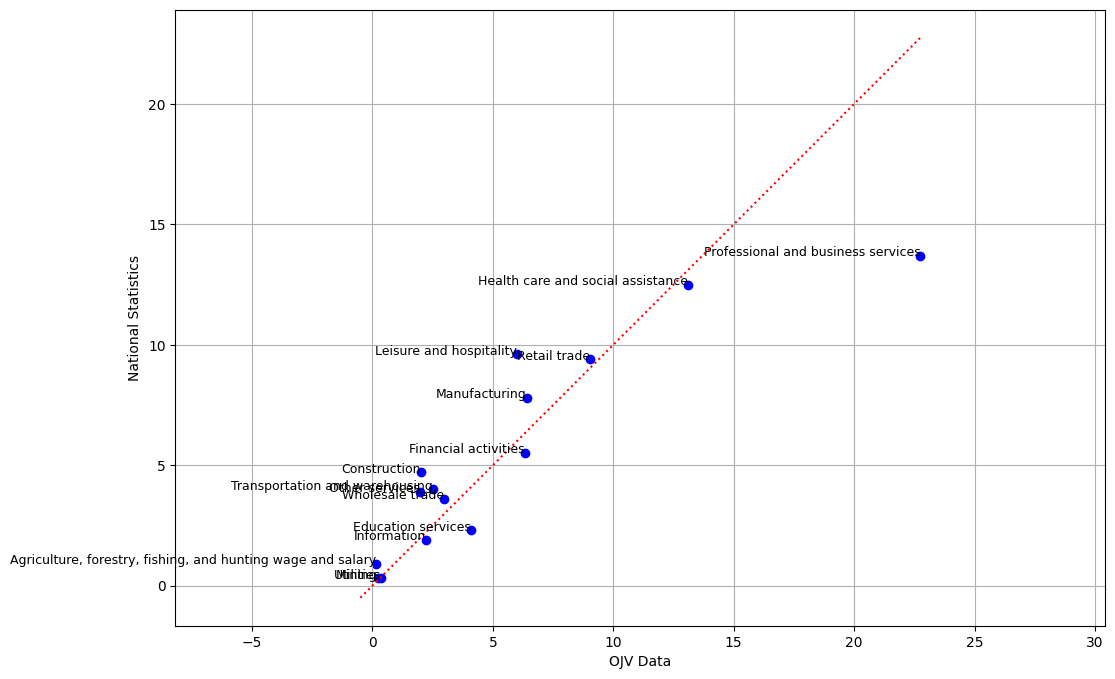

In [46]:
import matplotlib.pyplot as plt

# Filter out rows with missing values in either column
filtered_df = industry_comp.dropna(subset=['OJV Data', 'National Statistics'])

# Create a scatter plot
plt.figure(figsize=(12, 8))
plt.scatter(filtered_df['OJV Data'], filtered_df['National Statistics'], color='blue')

# Add labels for each point
for i, row in filtered_df.iterrows():
    plt.text(row['OJV Data'], row['National Statistics'], row['BLS_industry'], fontsize=9, ha='right')

# Set the labels and title
plt.xlabel('OJV Data')
plt.ylabel('National Statistics')
max_val = max(filtered_df['OJV Data'].max(), filtered_df['National Statistics'].max()) * 1

plt.plot([-0.5, max_val], [-0.5, max_val], linestyle='dotted', color='red')

# plt.title('Percentage vs National Statistics by BLS Industry')
plt.axis('equal')
# plt.xlim(0, max(filtered_df['OJV Data'].max(), filtered_df['National Statistics'].max()) * 1.1)
# plt.ylim(0, max(filtered_df['OJV Data'].max(), filtered_df['National Statistics'].max()) * 1.1)

# Show the plot
# Show the plot
plt.grid(True)
# save plot
plt.savefig('../figures/industry composition check/industry_comp_2024.png')
plt.show()


# Salary Sample

In [13]:
salary_data_sample = salary_data_sample.merge(industry_crosswalk, left_on = 'NAICS_2022_2', right_on = 'BLS_NAICS', how = 'left')

In [14]:
salary_data_sample.loc[salary_data_sample['BLS_industry'].isna(), 'BLS_industry'] = salary_data_sample.loc[salary_data_sample['BLS_industry'].isna(), 'NAICS_2022_2_NAME']

In [15]:
salary_data_sample.groupby('BLS_industry', dropna=False).size()

BLS_industry
Agriculture, forestry, fishing, and hunting wage and salary      30
Construction                                                    286
Education services                                              827
Financial activities                                           1762
Health care and social assistance                              1159
Information                                                    1014
Leisure and hospitality                                         643
Manufacturing                                                  1340
Mining                                                           23
Other services                                                  313
Professional and business services                             6071
Public Administration                                           546
Retail trade                                                   1144
Transportation and warehousing                                  462
Unclassified Industry              

In [16]:
# salary_data_sample.to_parquet('../data/salary_sample_body.parquet.gzip', compression='gzip')

In [20]:
grouped_industry_salary = get_grouped_industry(salary_data_sample)

In [23]:
industry_comp_salary = grouped_industry_salary.merge(bls_stats, left_on = 'BLS_industry', right_on = 'Industry name', how = 'outer')

In [24]:
industry_comp_salary = industry_comp_salary[['BLS_industry', 'Industry name','percentage', 'Percent distribution 2022']]

In [25]:
industry_comp_salary.rename(columns = {'percentage': 'OJV Data', 'Percent distribution 2022': 'National Statistics'}, inplace=True)

In [26]:
industry_comp_salary

,BLS_industry,Industry name,OJV Data,National Statistics
0,NaN,"Agriculture, forestry, fishing, and hunting se...",NaN,0.5
1,"Agriculture, forestry, fishing, and hunting wa...","Agriculture, forestry, fishing, and hunting wa...",0.150,0.9
2,Construction,Construction,1.430,4.7
3,Education services,Education services,4.135,2.3
4,NaN,Federal government,NaN,1.7
5,Financial activities,Financial activities,8.810,5.5
6,Health care and social assistance,Health care and social assistance,5.795,12.5
7,Information,Information,5.070,1.9
8,Leisure and hospitality,Leisure and hospitality,3.215,9.6
9,Manufacturing,Manufacturing,6.700,7.8


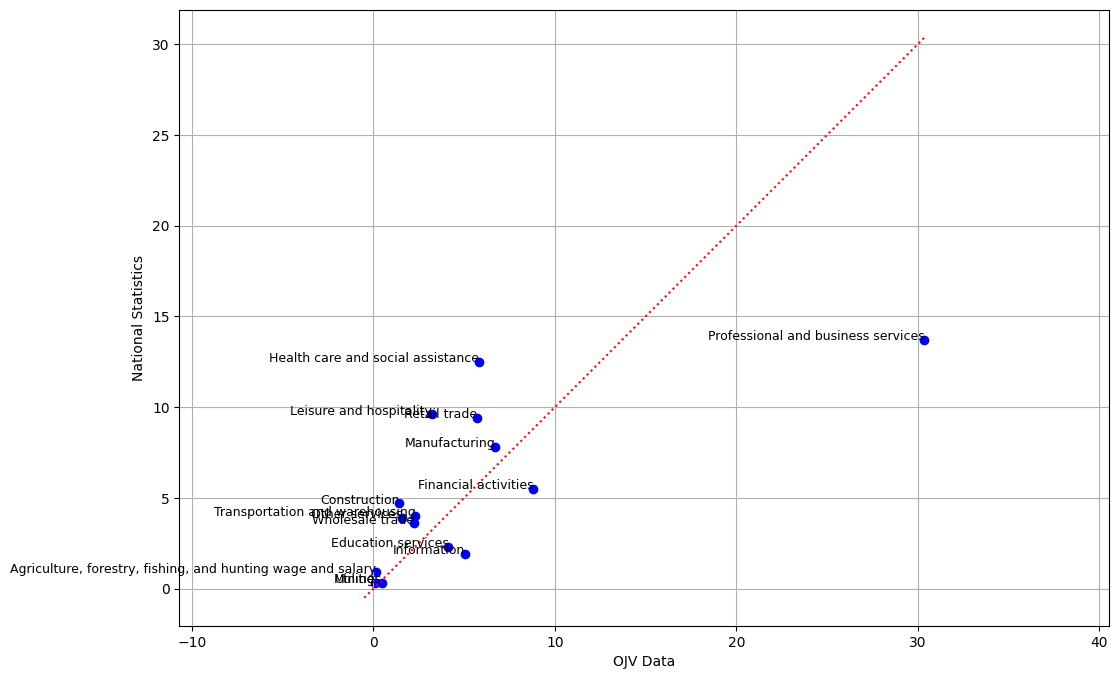

In [27]:
import matplotlib.pyplot as plt

# Filter out rows with missing values in either column
filtered_df_salary = industry_comp_salary.dropna(subset=['OJV Data', 'National Statistics'])

# Create a scatter plot
plt.figure(figsize=(12, 8))
plt.scatter(filtered_df_salary['OJV Data'], filtered_df_salary['National Statistics'], color='blue')

# Add labels for each point
for i, row in filtered_df_salary.iterrows():
    plt.text(row['OJV Data'], row['National Statistics'], row['BLS_industry'], fontsize=9, ha='right')

# Set the labels and title
plt.xlabel('OJV Data')
plt.ylabel('National Statistics')
max_val = max(filtered_df_salary['OJV Data'].max(), filtered_df_salary['National Statistics'].max()) * 1

plt.plot([-0.5, max_val], [-0.5, max_val], linestyle='dotted', color='red')

# plt.title('Percentage vs National Statistics by BLS Industry')
plt.axis('equal')
# plt.xlim(0, max(filtered_df_salary['OJV Data'].max(), filtered_df_salary['National Statistics'].max()) * 1.1)
# plt.ylim(0, max(filtered_df_salary['OJV Data'].max(), filtered_df_salary['National Statistics'].max()) * 1.1)

# Show the plot
# Show the plot
plt.grid(True)
# save plot
plt.savefig('../figures/industry composition check/ndustry_comp_2024_samplesalary.png')
plt.show()
